# 数值求导与偏导数（学生版）

本笔记按“概念 → 公式 → 代码 → 结果”的顺序组织，内容对应下方三段代码：

1) 中心差分：一元函数的数值导数
2) 网格与 3D 可视化：画出二元函数曲面
3) 数值梯度：对向量输入求偏导（梯度向量）


## 1. 中心差分：一元函数的数值导数

### 1.1 导数的想法

导数表示“函数在某一点的变化率”。严格定义是极限：

$$
 f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}
$$

计算机无法让 $h$ 真正变成 0，所以用一个很小的数来近似。

### 1.2 为什么用中心差分

中心差分公式：

$$
 f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}
$$

它左右对称，误差通常比“前向差分”更小。

### 1.3 对照代码理解

- `h=1e-4`：在精度与稳定性之间折中
- 只对一个点做“左右微小扰动”
- 用差分近似导数


In [2]:
# 中心差分（数值导数）

# 用中心差分近似一元函数在 x 处的导数

def numerical_diff(f, x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)


f = lambda x: x ** 2
print(numerical_diff(f, 5))  # 理论值是 10


h 0.0001
9.999999999976694


## 2. 偏导数：固定其他变量，只对一个变量求导

### 2.1 先把一个变量当常数

例如：

$$
 f(x,y)=x^2+xy+y^2
$$

固定 $x=a$，把 $x$ 当常量，则：

$$
 f_a(y)=a^2+ay+y^2
$$

对 $y$ 求导：

$$
 f'_a(y)=a+2y
$$

因此：

$$
 \frac{\partial f}{\partial y}(x,y)=x+2y
\quad\quad
 \frac{\partial f}{\partial x}(x,y)=2x+y
$$

### 2.2 偏导数的严格定义

$$
 \frac{\partial f}{\partial x_i}(a_1,\dots,a_n)=\lim_{\Delta x_i\to 0}\frac{f(a_1,\dots,a_i+\Delta x_i,\dots,a_n)-f(a_1,\dots,a_i,\dots,a_n)}{\Delta x_i}
$$

### 2.3 数值微分版

只改变一个自变量，其余保持不变：

$$
 \frac{\partial f}{\partial x} \approx \frac{f(x+h, y)-f(x-h, y)}{2h}
$$


## 3. 梯度：把偏导数组成一个向量

梯度就是把所有偏导数打包成向量：

$$
 \nabla f(x, y) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)
$$

直觉：梯度指向函数增长最快的方向，大小表示增长速度。


## 4. 网格与 3D 可视化（画出二元函数曲面）

要画 $f(x,y)$ 的曲面，需要在平面上取一张“网格”：

- `linspace` 生成一维坐标点
- `meshgrid` 把一维坐标扩展成二维网格
- 用 `Z = f(X, Y)` 计算每个网格点的函数值


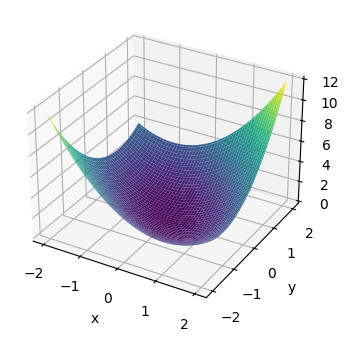

In [7]:
from matplotlib import pyplot as plt
import numpy as np

# 函数 f(x,y)=x^2+xy+y^2

def fun(x, y):
    return x ** 2 + x * y + y ** 2


# 在区间 [-2, 2] 取等间距点
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

# 生成二维网格坐标
X, Y = np.meshgrid(x, y)

# 注意：这里要用 X, Y（二维）而不是 x, y（一维）
Z = fun(X, Y)

# 画 3D 曲面
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
plt.show()


## 5. 数值梯度：对向量输入求偏导

数值梯度的思路：

- 让向量 $x$ 的第 $i$ 个元素加上一个很小的 $h$
- 只改变这一维，其余不变
- 计算函数值变化率，就得到第 $i$ 个偏导数

**注意：**此处的函数 `f` 必须返回一个标量（例如损失值）。


In [5]:
import numpy as np

# 数值梯度（中心差分）

def _numerical_gradient(f, x, h=1e-4):
    # 对向量 x 计算数值梯度（f 必须返回标量）
    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]

        x[idx] = tmp_val + h
        fxh1 = f(x)  # f(x + h * e_i)

        x[idx] = tmp_val - h
        fxh2 = f(x)  # f(x - h * e_i)

        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val  # 还原

    return grad


def fun(v):
    # 输入向量 v=[x, y]，返回标量 f(x,y)
    x, y = v[0], v[1]
    return x ** 2 + x * y + y ** 2


print("计算偏导数（数值梯度）")
print(_numerical_gradient(fun, np.array([1, 2])))  # 理论梯度是 [4, 5]


计算偏导数（数值梯度）
[4. 5.]


## 6. 公式小抄（汇总）

中心差分：

$$
 f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}
$$

偏导数（中心差分）：

$$
 \frac{\partial f}{\partial x} \approx \frac{f(x+h, y) - f(x-h, y)}{2h}
$$

$$
 \frac{\partial f}{\partial y} \approx \frac{f(x, y+h) - f(x, y-h)}{2h}
$$

梯度：

$$
 \nabla f(x, y) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)
$$


## 7. 练习题（配合代码）

1) **中心差分误差**：把 `h` 分别设为 $10^{-1}$、$10^{-3}$、$10^{-5}$，比较 `numerical_diff(f, 5)` 的结果，观察误差变化。为什么 `h` 太小也可能不稳定？

2) **手算 vs 数值**：函数 $f(x)=x^2$，在 $x=3$ 的真实导数是多少？用中心差分计算的结果接近吗？

3) **偏导数检查**：对 $f(x, y)=x^2 + xy + y^2$，手算 $\partial f/\partial x$ 和 $\partial f/\partial y$。取点 $(x, y)=(1,2)$，验证数值结果是否接近 $(4, 5)$。

4) **改函数**：把函数改成 $f(x, y)=\sin(x)+y^2$，写出解析偏导，并用中心差分验证。

5) **梯度方向**：在 $(1,2)$ 处，梯度为 $(4,5)$。如果沿着梯度方向走一步，函数值会变大还是变小？为什么？
